# Import libraries


In [1]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


Load cleaned dataset


In [4]:
# Load the cleaned retail sales dataset
df = pd.read_csv("../data/cleaned/retail_store_sales_cleaned.csv")

In [5]:
# Display the first five records
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


Check the data

In [6]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              12575 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  12575 non-null  bool   
dtypes: bool(1), float64(3), object(7)
memory usage: 994.8+ KB


In [7]:
# Check missing values
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

# Select features

In [8]:
# Select input features
X = df[[
    "Price Per Unit",
    "Quantity"
]]

# Select the target variable
y = df["Total Spent"]

# Display the feature data
X.head()

,Price Per Unit,Quantity
0,18.5,10.0
1,29.0,9.0
2,21.5,2.0
3,27.5,9.0
4,12.5,7.0


# Split Train and Test Data

In [9]:
# Split the dataset into training and testing sets
# 80% of the data is used for training
# 20% of the data is used for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the dataset sizes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (10060, 2)
Testing data: (2515, 2)


# Create Random Forest Model

In [10]:
# Create a Random Forest Regression model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


# Make Predictions

In [11]:
# Predict Total Spent for the test dataset

y_pred = model.predict(X_test)

# Display the first 10 predictions
print(y_pred[:10])

[164.         134.          40.          44.          96.
  43.         165.          82.          14.         164.14845677]


# Evaluate Model

In [12]:
# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

# Display model performance
print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 3.1325680582684936
Mean Squared Error  : 272.6991064161308
Root Mean Squared Error : 16.513603677457287
R2 Score : 0.9695585774332138


# Actual vs Predicted Visualization

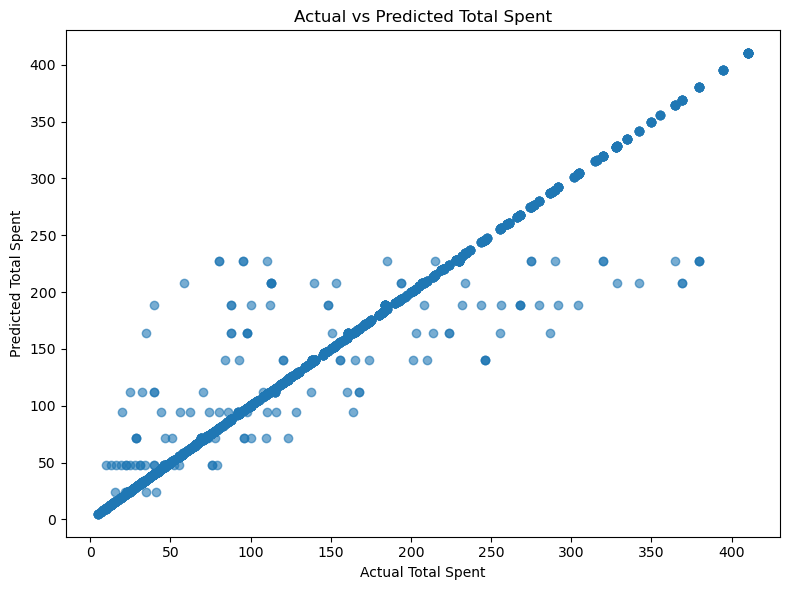

In [13]:
# Compare actual Total Spent values with predicted values

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Total Spent")
plt.ylabel("Predicted Total Spent")
plt.title("Actual vs Predicted Total Spent")

plt.tight_layout()

# Create visualization folder if required
import os
os.makedirs("../visualizations", exist_ok=True)

# Save the visualization
plt.savefig("../visualizations/actual_vs_predicted.png")

plt.show()

# Feature Importance

In [14]:
# Get feature importance values from the trained model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
feature_importance

,Feature,Importance
1,Quantity,0.516334
0,Price Per Unit,0.483666


# Visualize

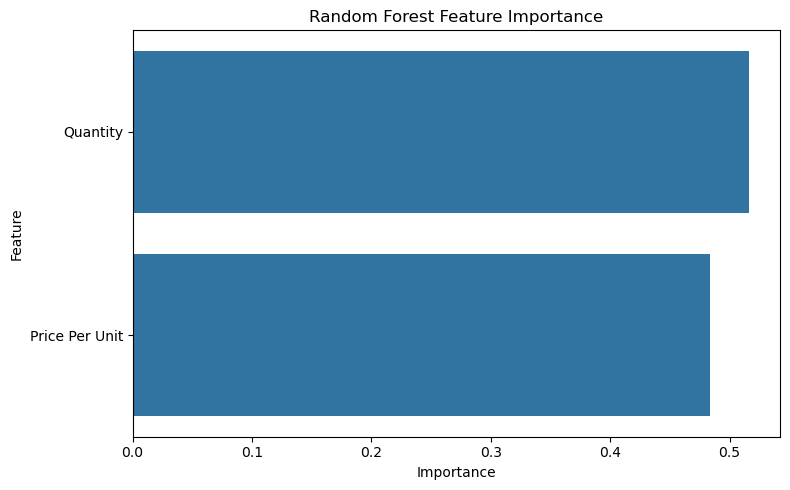

In [15]:
# Plot feature importance

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("../visualizations/feature_importance.png")

plt.show()

# Save Predictions

In [16]:
# Create a dataframe containing actual and predicted values

results = pd.DataFrame({
    "Actual Total Spent": y_test.values,
    "Predicted Total Spent": y_pred
})

# Save predictions
results.to_csv(
    "../data/cleaned/model_predictions.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!


# Final Model Summary #

# Model Summary

## Algorithm
Random Forest Regression

## Target Variable
Total Spent

## Input Features
- Price Per Unit
- Quantity

## Train-Test Split
- 80% Training Data
- 20% Testing Data

## Evaluation Metrics
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

## Visualizations
- Actual vs Predicted values
- Feature Importance

## Conclusion

The Random Forest Regression model was trained to predict
Total Spent based on Price Per Unit and Quantity.

Model performance was evaluated using MAE, MSE, RMSE and R² score.
Feature importance was also analyzed to understand the contribution
of the input variables.